# Assignment 2 - Spatial Data

***Student Name:***

Luca Barbera

***Student Number:***

S3705439

In this assignment, you will be asked to use your knowledge about spatial correlation functions and spatial weights to visualize several world bank data sets. Please be aware that your code is only part of the grade (60%). The actual visualization as well as your analytical approach in interpretation of the results will be graded as well (40%). The deadline for this assignment is **on 6th of November 2022, 23:55 PM**.


**Submit the notebook, and a html version of your notebook via the github Classroom repo**. Please use your studentnumber as file name (i.e. s145678.ipynb and s145678.html). If you do not include both the notebook and the html file, your submission will NOT be considered.
The easiest way to covert your notebook to an html file is to open it via jupyter notebook and then select File -> Download as -> HTML.  
**Please try to do this multiple days before the deadline so we can help you if you run into problems!**

Tasks:

    1) select 2 SDGs 
    2) formulate your research questions 
    3) transform data into weight matrices, make Moran's plots and interpret them
    4) display data in choropleth maps 
    5) answer your research questions in a short summary
 

In [1]:
%matplotlib inline

import seaborn as sns
import pandas as pd
import libpysal as ps
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Sustainable Development Goals & Shapefiles

On this website: https://www.un.org/sustainabledevelopment/sustainable-development-goals/ the UN summarizes their sustainable development goals (SDGs). 

Select two goals to work on for this assignment.


***I will be working on these two goals:***
    

Goal 15: Life on Land, Goal 11: Sustainable Cities and Communities

We would like you to focus on the African Continent for this exercise. Find shapefiles for the map of Africa and let us know where you found the shapefiles. Also let us know in which year the shapefiles were created and why this is relevant (hint: South Sudan). You might be able to find different shapefiles. Analyze your shapefiles. Like with any kind of "real" data, shapefiles can have *obstacles* that must be dealt with. For example, if your shapefile has islands, how do you define their adjacent countries? Shapefiles can also have *defects*. For example, an out of date shapefile might show old borders of a country, from when it used to border on another country that it's no longer adjacent to. Of course, if you're displaying historical data, that might be appropriate.
We want you to examine your shapefiles for obstacles, defects and other peculiarities. How will you handle them? Motivate your choice to use these specific shapefiles.

***Link to shapefiles:***

1) https://hub.arcgis.com/datasets/07610d73964e4d39ab62c4245d548625_0/about

***Year shapefiles were created:***


1) The shapefilese were published in 2014 and updated in January 2021.

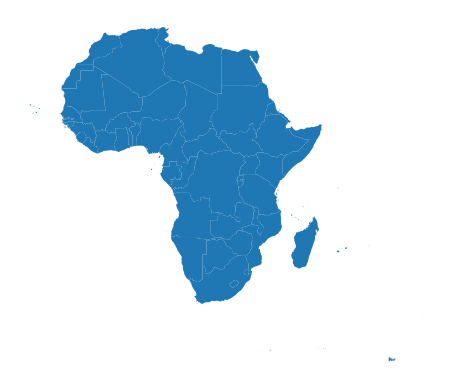

In [2]:
afr_shp = '/Users/lucajuliusbarbera/urban/assignment-2-lucabar/lab_data/myshapefiles/Africa_Boundaries/Africa_Boundaries.shp'

# Read the file in
afr = gpd.read_file(afr_shp)
# Display summary
# afr.info()

ax = afr.plot()
ax.set_axis_off()

# print(afr.head(15))

/Users/lucajuliusbarbera/opt/miniconda3/envs/holo/lib/python3.8/site-packages/libpysal/weights/weights.py:165: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 11 islands with ids: 1, 11, 12, 27, 29, 33, 35, 39, 46, 48, 54.
  warnings.warn(message)
/Users/lucajuliusbarbera/opt/miniconda3/envs/holo/lib/python3.8/site-packages/geopandas/plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


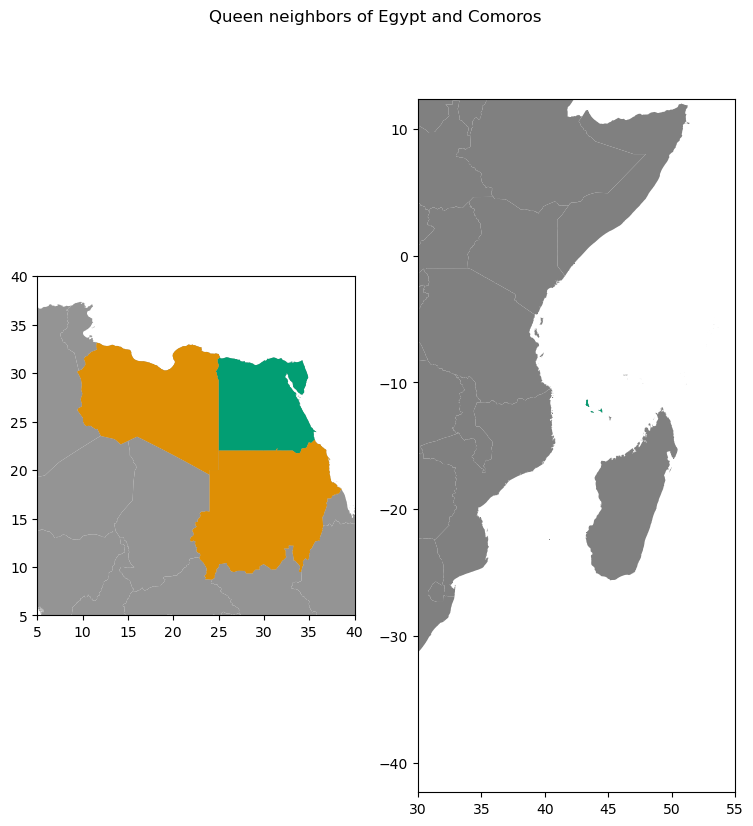

In [3]:
# choose color palette accessible to color blindness
plt.style.use('tableau-colorblind10')
colors = sns.color_palette('colorblind', 10)

w_queen = ps.weights.Queen.from_shapefile(afr_shp)
country_id1 = 14
# Setup figure
f, ax = plt.subplots(1,2, figsize=(9, 9))
# Plot base layer of polygons
afr.plot(ax=ax[0], facecolor=colors[7], linewidth=0.5)
# Select focal polygon
# NOTE we pass both the area code and the column name
#      (`geometry`) within brackets!!!
focus = afr.loc[[country_id1], ['geometry']]
# Plot focal polygon
focus.plot(facecolor=colors[2], alpha=1, linewidth=0, ax=ax[0])
# Plot neighbors
neis = afr.loc[w_queen.neighbors[country_id1], :]
neis.plot(ax=ax[0], facecolor=colors[1], linewidth=0)
ax[0].set_xlim(5, 40)
ax[0].set_ylim(5, 40)

country_id2 = 11
afr.plot(ax=ax[1], facecolor='gray', linewidth=0.5)
focus = afr.loc[[country_id2], ['geometry']]
# Plot focal polygon
focus.plot(facecolor=colors[2], alpha=1, linewidth=0, ax=ax[1])
# Plot neighbors
neis = afr.loc[w_queen.neighbors[country_id2], :]
neis.plot(ax=ax[1], facecolor=colors[1], linewidth=0)

# Title
f.suptitle(f"Queen neighbors of {afr['NAME_0'][country_id1]} and {afr['NAME_0'][country_id2]}")
# Style and display on screen
# ax.set_axis_off()
plt.axis('equal')

ax[1].set_xlim(30, 55)
ax[1].set_ylim(-30, 0)
plt.show()

***Motivation for selecting the shapefile:***

It includes the boundaries of all countries on the African continent and international shorelines, including off-shore islands. In the abstract of the file it is noted that the accuracy of the boundaries is accurate to a few hundred meters or less, while the international shorelines can vary up to many hundred meters up to more than a kilometer. The first *obstacle* that must be noticed is that the borders are displayed according to the U.S. government (USG) policy, which means that countries/areas that are not recognised by the USG will not be mentioned and thus not accurately displayed.  South Sudan, which gained independence in 2011, is correctly depicted, but I am unaware of any other border changes since 2014 in Africa. These, of course, would not be included in these shapefiles. Even though the United States do not officially recognize Western Sahara as an independent state, it is still depicted with its own borders and identity.
Clearly, (Queen) **neighbours** of Islands are non existing as can be seen in the right plot and also neighbours on different continents (in the case of Egypt on the left) are not shown either.
To circumvent the former problem of islands' neighbours, we could use the k-nearest neighbour metric in order to find, not adjacent, but close lying countries: see below.

[2) These shapefiles contain data of average above+below ground biomass tonnage/hectar in Africa and the entire world. As this information is drawn from sattelite pictures of forest, savannah, and grassland landcover and synthetic non-forest biomass stock estimates, it is prone to more uncertainty than internationally agreed upon state borders as seen above. For example, when available, the above and below ground biomass was averaged, but in the whole area of croplands no below ground ratios were available. Furthermore, biomass is not a well defined quantity. For above-ground woody biomass, only trees with a diameter of >10cm at breast height are counted and the oven-dry mass is taken. How is this comparable of biomass of grassland? This needs to be taken into account when comparing biomass of different types of land. The data seems "favourable" to forests as they are hotspots of biomass aggregation when measured this way. Resolutions varied for each dataset and were gauged to the lowest resolution of 300m.]

/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/152091366.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cents = afr.centroid
/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/152091366.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buf = focus.centroid.buffer(radius)
/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/152091366.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buf = focus.centroid.buffer(radius)
/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/152091366.py:28: UserWarning: Geometry is in a

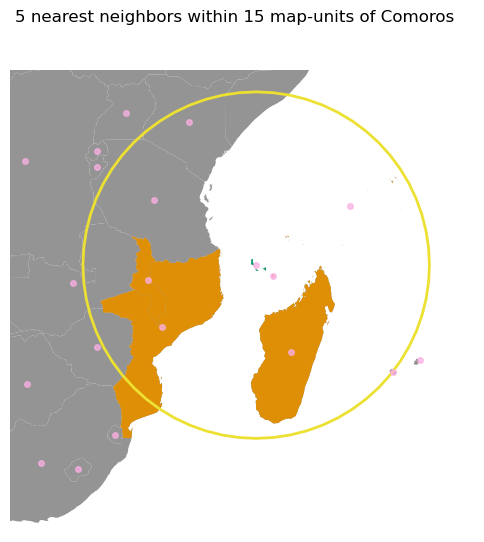

In [4]:
knn5 = ps.weights.KNN.from_shapefile(afr_shp, k=5)

# Extract centroids
cents = afr.centroid
# Extract coordinates into an array
pts = np.array([(pt.x, pt.y) for pt in cents])
# Compute KNN weights
knn5_from_pts = ps.weights.KNN.from_array(pts, k=5)
radius = 15
country_id = 11
# Setup figure
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot base layer of polygons
afr.plot(ax=ax, facecolor=colors[7], linewidth=10)
# Select focal polygon
# NOTE we pass both the area code and the column name
#      (`geometry`) within brackets!!!
focus = afr.loc[[country_id], ['geometry']]
# Plot focal polygon
focus.plot(facecolor=colors[2], alpha=1, linewidth=0, ax=ax)
# Plot neighbors
neis = afr.loc[list(knn5_from_pts[country_id].keys()), :]
neis.plot(ax=ax, facecolor=colors[1], linewidth=0)
# Plot 1km buffer
buf = focus.centroid.buffer(radius)
buf.plot(edgecolor=colors[8], alpha=1, fc="none", lw=2, ax=ax)
# Plot centroids of neighbor
pts = np.array([(pt.x, pt.y) for pt in afr.centroid])
ax.plot(pts[:, 0], pts[:, 1], color=colors[6], 
        linewidth=0, alpha=0.75, marker='o', markersize=4)
#afr.centroid.plot(axes=ax)
# Title
f.suptitle(f"5 nearest neighbors within {radius} map-units of {afr['NAME_0'][country_id]}")
# Style, zoom and display on screen
ax.set_axis_off()
plt.axis('equal')
ax.set_xlim(25, 60)
ax.set_ylim(-35, 5)
plt.show()

## Task 2: Research Questions & Data Sources

For every SDG, you can find "Goal x targets" on the UN website. Use these targets to formulate at least one question per SDG (i.e., at least two questions that you want to answer). The question can be about the current state of a SDG in Africa, comparing countries/regions within Africa or a longitudinal comparison of a region. 

Make your research question concrete. Something like "What is the state of SDG 7 in Africa?" is too broad. Something like: "Using variable x a proxy for the development of SDG 7, how do the West-African Countries fare compared to the rest of Africa?" is much more concrete, and narrows your question down to an achievable outcome. It also gives you something to discuss in your report.   

Discuss your research question on MS Teams if you are not sure. Help each other, also by asking for help if you are not used to formulate research questions yourself! 

We will answer questions and doubts about research questions on Teams until **October 31st**. That means: if you would like to have us check your question before you continue working on this assignment, make sure you post it until October 31st, we will answer as quickly as possible. After October 31th , we will not check individual research questions, but you will still be able to see what we answered and you can refer to the forum as a guideline. 


***1st research question:***



SDG 15: What is the current status of **deforestation (forest area in % of land area)** in Central African regions, what are local communities and government policies doing against it, and how does it compare to other African countries?

***2nd research question:***

SDG 11: Using **urbanization rates (urban population growth in %)** as a metric, how do the East African cities compare to the rest of Africa in terms of their progress towards becoming more sustainable and resilient urban centers?

In [5]:
forest_t = 'Forest area [%] (2020)'
urban_t = 'Urban population growth [%] (2020)'
afr2 = afr

# include World Bank data into dataframe
forest = pd.read_csv('/Users/lucajuliusbarbera/urban/assignment-2-lucabar/lab_data/myshapefiles/sdg_csv/forest-data.csv', usecols=(3,15), names=["ISO", forest_t], header=None,skiprows=1)
urbanpop = pd.read_csv('/Users/lucajuliusbarbera/urban/assignment-2-lucabar/lab_data/myshapefiles/sdg_csv/urban-data.csv', usecols=(3,15), names=["ISO", urban_t], header=None,skiprows=1)
# add information about regions to be able to compare afterwards
cc = pd.read_csv('/Users/lucajuliusbarbera/urban/assignment-2-lucabar/lab_data/myshapefiles/sdg_csv/country-codes.csv', usecols=(2,5,7), names=["ISO","Continent","region"], header=None,skiprows=1)
cc = cc[cc["Continent"] == "Africa"]  # filter out non-african countries
cc = cc.drop(["Continent"], axis=1)  # drop information on continent
# there is a problem with Northern Africa in the CSV, so need to name it manually
cc['region'].fillna("Northern Africa", inplace=True)


afr2 = pd.merge(afr2, forest, on='ISO', how='left',)
afr2 = pd.merge(afr2, urbanpop, on='ISO', how='left')
afr2 = pd.merge(afr2, cc, on='ISO', how='left')
afr2 = afr2.dropna(subset=["ISO"])
afr2 = afr2.dropna(subset=[forest_t])
afr2 = afr2.drop(['Continent',"REgion",'OBJECTID'],axis=1)

#create table with only central african countries
afr_c = afr2[afr2["region"]=="Middle Africa"]
afr_e = afr2[afr2["region"]=="Eastern Africa"]

print(len(afr2),"countries in Africa on which we have forest and urban data")
print('Table of East African countries','\n\n',afr_e.head())

53 countries in Africa on which we have forest and urban data
Table of East African countries 

     ISO    NAME_0                                           geometry  \
2   BDI   Burundi  POLYGON ((30.41152 -2.31061, 30.41243 -2.31180...   
11  COM   Comoros  MULTIPOLYGON (((43.71569 -12.40097, 43.71569 -...   
15  ERI   Eritrea  MULTIPOLYGON (((42.93125 12.82153, 42.93125 12...   
17  ETH  Ethiopia  POLYGON ((38.13777 14.68389, 38.14972 14.68278...   
24  KEN     Kenya  MULTIPOLYGON (((39.37625 -4.71569, 39.37625 -4...   

    Forest area [%] (2020)  Urban population growth [%] (2020)          region  
2                10.889408                            5.602624  Eastern Africa  
11               17.689414                            2.912201  Eastern Africa  
15               10.448119                            2.947876  Eastern Africa  
17               15.114225                            4.731593  Eastern Africa  
24                6.344818                            4.010418  E

On the worldbank website, you can easily find matching data: https://datacatalog.worldbank.org/dataset/sustainable-development-goals. You are free to use other data sources. Make sure to share them with us though. 

**Important:**

! We want to re-run your analyses, so please include a link to the data that you are using in your submission!




***Links to data:***

1) https://databank.worldbank.org/reports.aspx?dsid=46&series=AG.LND.FRST.ZS deforestation of central African countries (e.g. Rep. Congo, Dem.Rep. Congo, Cameroon, Uganda, Rwanda) from 1990-2020
2) https://databank.worldbank.org/reports.aspx?dsid=46&series=SP.URB.GROW urbanization of east African countries (e.g. Kenya, Uganda, Somalia, Ethiopia, Tanzania)
3) https://github.com/lukes/ISO-3166-Countries-with-Regional-Codes/blob/master/all/all.csv for intermediate-region data

## Task 3: Spatial Lag & Moran's Plot

In Lab 4 (http://darribas.org/gds16/labs/Lab_04.html) by Dani Arribas, you can see examples of weight matrices and at the end an explanation of spatial lag and the Morans plot (Watch out, this is not Moran's I/ Moran's spatial autocorrelation, which is also often calculated in spatial analytics), We have provided a modified version of this lab ready to go in this repo. 
Read and understand the concept of spatial lag first. In a Moran's plot, you can show how the value of a variable relates to it's spatial lag (or the average of this value in the surrounding areas). 

Additional information: 
* [Dani Arribas written course material](http://darribas.org/gds_scipy16/)
* [installing PySAL](https://pysal.org/docs/install/) and [PySAL tutorial](https://pysal.org/libpysal/tutorial.html)

Your tasks:

1) Create two Morans plots based on the variables related to your research questions and interpret them: 

2) What can you say about the entire continent?

3) Can you find meaningful subregions? 

4) What if you use block weights around those subregions and re-run the analysis? 

/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/3410541807.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cents = afr2.centroid
/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/3410541807.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cents_c = afr_c.centroid
/var/folders/68/x8klff196fl8_dk1n2t0qbtc0000gn/T/ipykernel_885/3410541807.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cents_e = afr_e.centroid


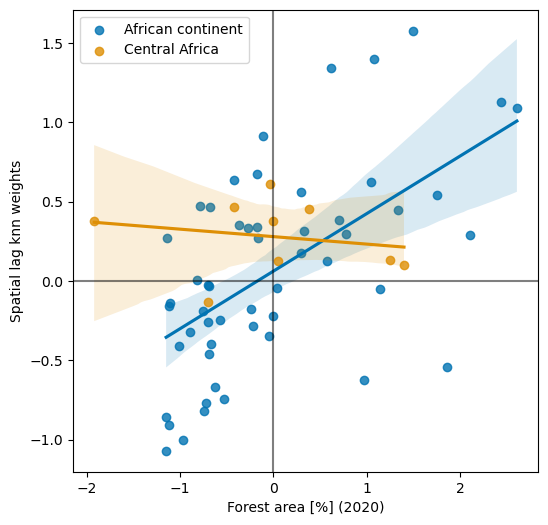

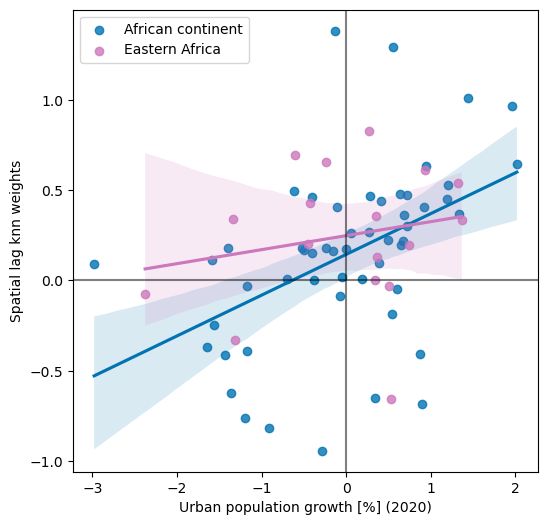

In [6]:
# choose color palette accessible to color blindness
plt.style.use('tableau-colorblind10')
colors = sns.color_palette('colorblind', 5)

# distance based metric for all african countries, for central and for eastern
# Extract centroids
cents = afr2.centroid
cents_c = afr_c.centroid
cents_e = afr_e.centroid
# Extract coordinates into an array
pts = np.array([(pt.x, pt.y) for pt in cents])
pts_c = np.array([(pt.x, pt.y) for pt in cents_c])
pts_e = np.array([(pt.x, pt.y) for pt in cents_e])

# Compute KNN weights
knn5_weights = ps.weights.KNN.from_array(pts, k=5)
knn5_weights_c = ps.weights.KNN.from_array(pts_c, k=5)
knn5_weights_e = ps.weights.KNN.from_array(pts_e, k=5)
# re-normalise
knn5_weights.transform = "R"
knn5_weights_c.transform = "R"
knn5_weights_e.transform = "R"

# Standardize in the case of forestation
std_afr = (afr2[forest_t] - afr2[forest_t].mean()) / afr2[forest_t].std()
std_afr_c = (afr_c[forest_t] - afr_c[forest_t].mean()) / afr_c[forest_t].std()

# Compute the spatial lag of the standardized version and save is as a 
# Series indexed as the original variable
std_w_afr = pd.Series(ps.weights.lag_spatial(knn5_weights, std_afr), index=std_afr.index)
std_w_afr_c = pd.Series(ps.weights.lag_spatial(knn5_weights_c, std_afr_c), index=std_afr_c.index)
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(x=std_afr, y=std_w_afr,label='African continent',color=colors[0])
sns.regplot(x=std_afr_c, y=std_w_afr_c,label='Central Africa',color=colors[1])

ax.set_ylabel("Spatial lag knn weights")
ax.set_xlabel(forest_t)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.legend()
plt.show()


# Standardize in the case of urban population growth
std_afr = (afr2[urban_t] - afr2[urban_t].mean()) / afr2[urban_t].std()
std_afr_e = (afr_e[urban_t] - afr_e[urban_t].mean()) / afr_e[urban_t].std()

# Compute the spatial lag of the standardized version and save is as a 
# Series indexed as the original variable
std_w_afr = pd.Series(ps.weights.lag_spatial(knn5_weights, std_afr), index=std_afr.index)
std_w_afr_e = pd.Series(ps.weights.lag_spatial(knn5_weights_e, std_afr_e), index=std_afr_e.index)
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(x=std_afr, y=std_w_afr,label='African continent',color=colors[0])
sns.regplot(x=std_afr_e, y=std_w_afr_e,label='Eastern Africa',color=colors[4])

ax.set_xlabel(urban_t)
ax.set_ylabel("Spatial lag knn weights")
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.legend()
plt.show()

***Interpretation of Moran's Plot:***

When looking at the overall continent, the upper right and lower left quadrant (high-high and low-low) seem to be more populated than the other two and thus are significant subregions. This indicates an overall positive spatial autocorrelation of the variable regarding its neighbours. It makes sense, that a country with a lot of forest area will have a neighbour with also a significant amount of forest and that increase in urbanization also happens similarly in adjacent countries. Of course, on the African continent we are talking about gigantic distances (compared to European), such that a simple "neighbour" can be hundreds if not thousands of kilometers from the center of one country and vegetation and urban population can change even more. Here, the forest area seems to be more strongly positively autocorrelated than the urban population growth, which is a bit more spread out.

Now, when looking only at Central African countries (first plot, yellow color), we see that these either have an above average forest area or are surrounded by countries that do. Here it is important to notice that the differently colored plots are not standardized over the entire continent but just the intermediate region. As mentioned above, the spatial correlation of forest area and other vegetation is positively autocorrelated, as these are border-transgressing variables that change on large scales and distances.

Also, Eastern African countries (second plot, violet color) seem to have an above average urban population growth, which is why it was interesting to me in the first place to pose this research question. Here, however, the standard deviation reaches further into the bottom half and many Eastern African countries either have a weaker urban population growth than their neighbours (top left quadrant) or are more densly populated than their neighbours (bottom right quadrant). 

/Users/lucajuliusbarbera/opt/miniconda3/envs/holo/lib/python3.8/site-packages/libpysal/weights/weights.py:165: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  warnings.warn(message)


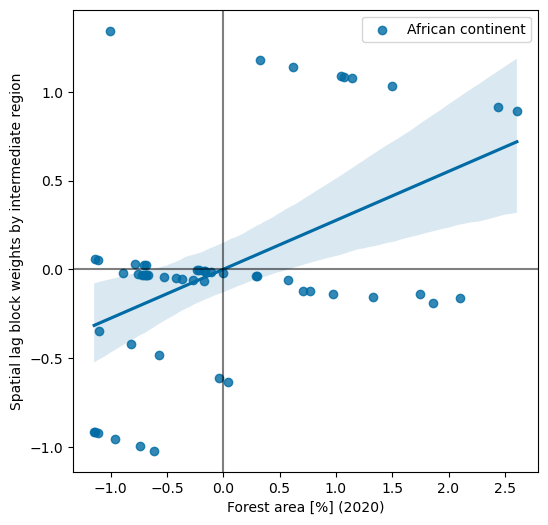

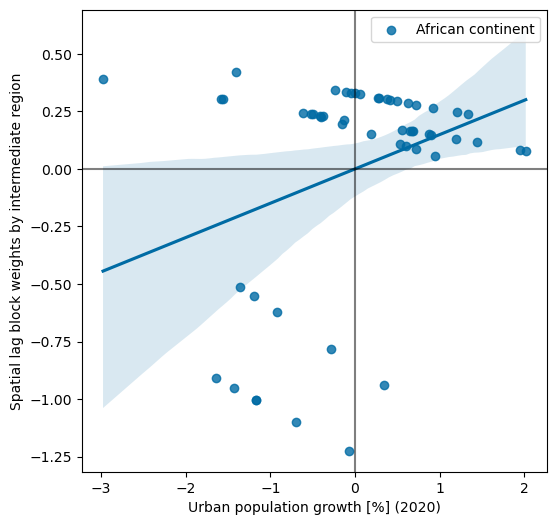

In [7]:
w_block = ps.weights.block_weights(afr2['region'])

w_block.transform = "R"

# Standardize in the case of forestation
std_afr = (afr2[forest_t] - afr2[forest_t].mean()) / afr2[forest_t].std()

# Compute the spatial lag of the standardized version and save is as a 
# Series indexed as the original variable
std_w_afr = pd.Series(ps.weights.lag_spatial(w_block, std_afr), index=std_afr.index)

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(x=std_afr, y=std_w_afr,label='African continent')

ax.set_ylabel("Spatial lag block weights by intermediate region")
ax.set_xlabel(forest_t)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.legend()
plt.show()


# Standardize in the case of urban population growth
std_afr = (afr2[urban_t] - afr2[urban_t].mean()) / afr2[urban_t].std()

# Compute the spatial lag of the standardized version and save is as a 
# Series indexed as the original variable
std_w_afr = pd.Series(ps.weights.lag_spatial(w_block, std_afr), index=std_afr.index)

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(x=std_afr, y=std_w_afr,label='African continent')

ax.set_xlabel(urban_t)
ax.set_ylabel("Spatial lag block weights by intermediate region")
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.legend()
plt.show()

Above I analysed the entire African continent, but clustered into intermediate regions (Middle, North, East, West, South) and calculated their block weights accordingly. We can see a clearly positive spatial autocorrelation by the more populated HH and LL quadrants of the plot. Mean value and standard variation clearly have the same tendency. This just reaffirms our thesis that factors forest area and urban population growth are spatially correlated and there is normally no sudden change to neighbours, whether we define them as k-nearest or belonging to the same technical definition of a intermediate region.

In both cases, one would not only have to look at spatial data to say anything about the SDG targets, but definitely also temporal data. We would have to analyse these variables over the past decade or more to understand what policies might have a positive/negative influence on the target. This way we can just look at a snapshot of the situation without knowing whether it's progressing or not.

## Task 4: Choropleth Maps

Use the same two variables you used in Task 3 and create a Choropleth Map. A choropleth map is a type of map which uses differences in shading, colouring, or the placing of symbols within predefined areas to indicate the average values of a particular quantity in those areas. Do a research on color-blindness and how to avoid it in creating visualisation. Choose a color-blind proof colour combination. Indicate where you found it and why you trust it with color-blind proofness. 


Does the map correspond to the findings in Morans plot?


***Chosen Colour map & motivation:*** 

https://www.cta-observatory.org/wp-content/uploads/2020/10/CTA_ColourBlindness_BestPractices-1.pdf (cherenkov telescope array - Astrodiversity project on best pracitces for color blind friendly publications)

The project seemed serious, well researched and its suggestions overlap with what I found on wikipedia (to use "plasma","viridis" or "cividis" colormaps). I checked the Matplotlib documentation for their explanation of colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html#color-vision-deficiencies and their effect on color-vision-deficiencies.

I also showed this to a friend of mine who is colorblind and he could see everything perfectly.

***Choropleth Maps***

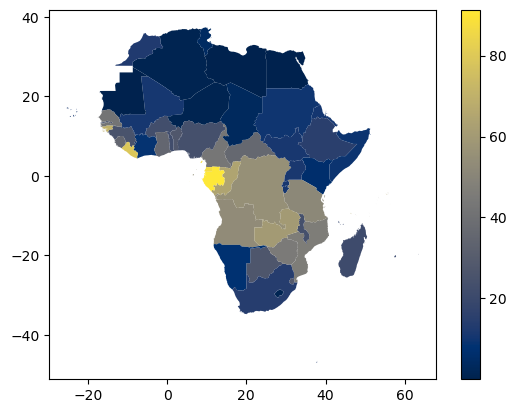

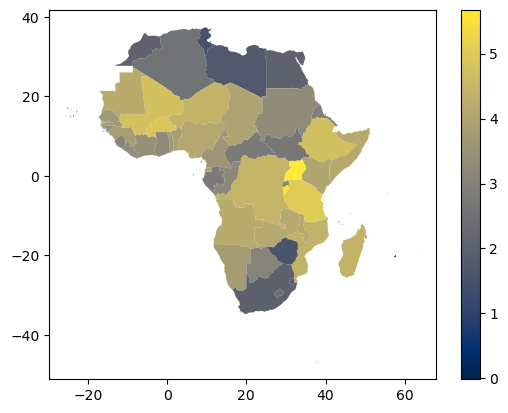

In [8]:
# Choropleth Maps
afr2.plot(column=forest_t, cmap='cividis', legend=True)
# plt.savefig('forest.pdf')
plt.show()

afr2.plot(column=urban_t, cmap='cividis', legend=True)
# plt.savefig('urbanpop.pdf')
plt.show()

***Interpretation:***

(Note that some countries are not displayed correctly due to missing data from the world bank.)
The first thing that one notices is that both Moran's plots suggest more similarity in distribution of the observed variables than the choropleth maps suggest. In the case of forest area, there is a clear drop from high density in Central and West Africa down to low density in the rest of Africa. This supports the claim of our first Moran plot where Central African countries are seen to have a higher-than-average forest density.

In the case of urbanisation it is clear to see that traditionally less industrialised countries (non-North African and not South Africa) have a much higher rate in urban population growth. This way, most of Africa is one big urbanising cluster while the North and far South stand out. Both cases support the claim of high spatial autocorrelation, just around different clusters.

## Task 5: Report

You visualized two variables related to your research questions. How would you interpret your findings and how does it help you to answer your research questions? 

Which extra variables would you like to use? What information are you missing in your current data? What kind of data could you use to improve your analysis?

Try to answer your research questions and don't shy away from suggesting future research. 

***Answer your research questions in 200-400 words:***

The variables I analysed and visualised are forest area in % of total area and growth of the urban population on the African continent. The former case more specifically with respect to central African countries and their goal to combat deforestation and strengthen local fauna. The latter case would focus on Eastern African urban development and their approach on sustainable and resilient cities.

Firstly, I must say that a mere snapshot (in time) of a single scalar variable observed over a whole continent cannot possibly give answers to complex questions regarding targets for the sustainable development goals. My initial goal was to see what communities and policies are doing to combat deforestation but for this one would have to consider a time series of choropleth maps and Moran plots in order to deduce the impacts of such changes. When looking at the full table available at the world bank, it becomes clear that over time the % in forest area have declined in almost every African country. Here, it would actually be very interesting to compare how the high-density clusters we could identify in the choropleth map (West Africa, Central Africa) develop differently than low-forest-density countries in the North and East. If all were shrinking by the same rate this could be attributed to overall climate change or the need of wood, but if you could identify a faster shrinkeage in the densely forested areas, we could probably trace this back to community or government policy action (here I have to think about the impact the Brasilian government has on the rate of deforestation of the Amazon rainforest).

Also, to what extent the mere growth of the urban population correlates with measures to increase sustainability and resilience in the cities is completely unknown. We only know that it becomes more and more important to create liveable cities, as we see the urban heat island (UHI) effect and the increase in impervious surface coverage. I am thinking of including this in my final report as well, as there are machine learning techniques in estimating the UHI effect, but this is besides the point.

As with the case of forestation, we can see that the urban research question was posed like this due to my understanding that urban population growth in Eastern African countries was higher than the African average. This was confirmed by both the Moran plot and the choropleth graph. The outliers in the urban Moran plot that indicate negative autocorrelation (LH or HL quadrant) correspond to outliers in the choropleth graph like South Sudan and Eritrea where urban population growth is not as distinct due to a range of reasons. We see that we cannot draw clear lines of local correspondence but that the overall trend is visible.

To go beyond assumptions of the status quo and to analyse policies and their influences, we would have to include a non-quantitative criterion of "what policy was implemented when" and measure their effect on the variables observed (again this would require spatio-temporal data).

## How do we grade this assignment?
Please pay attention to the following points. We consider these in calculating your final grade.

First of all, we check if you have handed in the Jupyter notebook as well as a .pdf and .html version.

1st part


1.   We inspect the access to the correct shapefile from the link you have provides.
2.   We consider if the shapefile is suitable for answering your research question.
3. We consider your reasoning and motivation for selecting the shapefile.



2nd part
1. We consider the validity, scope and concreteness of the questions.
2. We inspect the data sources.


3rd part
1. We consider the Moran plots.
2. We consider the interpretations of the plots.

4th part
1. We consider the choropleth maps.
2. We consider the color scheme used in the maps and that a right process is used for selecting the color scheme.

5th part 
1. We consider the quality of your report and if each research question is concretely answered. 
2. We consider your reflection on the data you used.
3. We consider the interpretations deduced from the plots.
4. We consider your ideas for additional data and further research.
